# Recreate Rubiks Cube env

Create a custom gymnasuim environment representing a rubiks cube. 


Afterwards, create a model to solve it

## Env

In [1]:

from __future__ import annotations

from typing import Any, Optional

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import random

from pathlib import Path
import torch

In [2]:
class RubiksCube(gym.Env):
    metadata = {
        "render_modes": ["human", "rgb_array", "ansi"],#unused
        "render_fps": 30,#unused
    }

    def __init__(
        self,
        render_mode: Optional[str] = None,
        max_steps: int = 200,
    ):
        super().__init__()

        self.render_mode = render_mode
        self.max_steps = max_steps

        # Example: 4 discrete actions
        self.action_space = spaces.Discrete(12)

        # Example: 1D continuous observation vector of length 5
        self.observation_space = spaces.Box(
            low=0,
            high=5,
            shape=(54*6,),#6 3x3 faces in a 1d array. each of which is one of 6 colors represented as an int 0 to 5
            dtype=np.int8, #color
        )

        self.state = []
        self.step_count = 0
        self.faces_completed = 0
        self.is_completed = False

        # Optional render state
        self.window = None
        self.clock = None
        

    def _get_obs(self) -> np.ndarray:
        colors = np.array([int(p[3]) for p in self.state])
        return np.eye(int(colors.max())+1,dtype=np.float64)[colors].flatten()

    def _get_info(self) -> dict[str, Any]:
        return {
            "step_count": self.step_count,
            "faces_completed":self.faces_completed,
            'n_scramble':self.n_scramble,
            #num correct faces
        }

    def reset(
            self,
            *,
            seed: Optional[int] = None,
            options: Optional[dict[str, Any]] = None,
            n_scramble = 26
            ) -> tuple[np.ndarray, dict[str, Any]]:
        super().reset(seed=seed)
        self.n_scramble = n_scramble
        self.step_count = 0

        # solved initial state
        self.state = self.place_points_on_cube_faces()

        # make random moves n times
        for _ in range(n_scramble):
            self.move(random.randint(0,11))
        
        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, info

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        assert self.action_space.contains(action), f"Invalid action: {action}"

        self.step_count += 1
        #take action
        self.move(action)
        
        
        reward,terminated = self._get_reward()

        # ---- Termination logic (task-defined) ----
        # terminated,_ = self._check_cube_completion()
        # ------------------------------------------

        # ---- Truncation logic (outside MDP, e.g. time limit) ----
        truncated = self.step_count >= self.max_steps
        # ---------------------------------------------------------

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, reward, terminated, truncated, info
        
    def _check_cube_completion(self):
        faces = ['front','back','left','right','top','bottom']
        is_completed = True
        num_faces_completed = 0
        for face in faces:
            face_pts,_ = self.get_face(self.state,face,exclude_sides=True)
            face_colors = [p[3] for p in face_pts]
            if len(set(face_colors)) == 1:
                num_faces_completed += 1
            if len(set(face_colors))> 1:
                is_completed = False
        self.faces_completed = num_faces_completed
        self.is_completed = is_completed
        return is_completed,num_faces_completed
        
    def _get_reward(self,reward_type='absolute'):
        is_completed,faces_completed = self._check_cube_completion()
        if reward_type == 'absolute':
            #only reward for completing cube
            return is_completed * 100 + -0.1, is_completed
        elif reward_type == 'breadcrumb':
            return is_completed * 100 + faces_completed -0.01, is_completed
        # elif too many steps, large negative

    
            
    def render(self,radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        # def plot_points_on_sphere(points, radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        """
        Plot a list of 3D Cartesian coordinates on a sphere.
    
        Parameters
        ----------
        points : list of tuple[float, float, float]
            List of (x, y, z) coordinates.
        radius : float
            Radius of the sphere.
        sphere_alpha : float
            Transparency of the sphere surface.
        point_color : str
            Color of plotted points.
        point_size : int
            Size of plotted points.
        """
        points = self.state
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    
        # Create sphere surface
        u = np.linspace(0, 2 * np.pi, 100)
        v = np.linspace(0, np.pi, 100)
        x = radius * np.outer(np.cos(u), np.sin(v))
        y = radius * np.outer(np.sin(u), np.sin(v))
        z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    
        ax.plot_surface(x, y, z, color='lightblue', alpha=sphere_alpha, edgecolor='none')
    
        # Plot input points
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   # color=points[:,3],
                   c=points[:,3],
                   cmap='viridis',
                   s=point_size)
    
        # Keep aspect ratio equal
        ax.set_box_aspect([1, 1, 1])
    
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title("Points on a Sphere")
    
        plt.show()

    def close(self):
        #undo anything opened from self.render
        plt.close()

    def rotate_point_on_sphere(self,point, axis, direction=1):
        """
        Rotate a 3D point on a sphere by +/- 90 degrees around a given axis.
    
        Parameters
        ----------
        point : tuple or array-like
            The (x, y, z) point to rotate.
        axis : tuple or array-like
            The axis of rotation as a 3D vector.
        direction : int
            +1 for +90 degrees, -1 for -90 degrees.
    
        Returns
        -------
        np.ndarray
            Rotated point as a length-3 array.
        """
        color = point[3]
        point = point[:3]
        p = np.asarray(point, dtype=float)
        k = np.asarray(axis, dtype=float)
    
        if np.linalg.norm(k) == 0:
            raise ValueError("axis must be non-zero")
        if direction not in (+1, -1):
            raise ValueError("direction must be +1 or -1")
    
        k = k / np.linalg.norm(k)
        theta = direction * np.pi / 2  # 90 degrees
    
        # Rodrigues' rotation formula
        p_rot = (
            p * np.cos(theta)
            + np.cross(k, p) * np.sin(theta)
            + k * np.dot(k, p) * (1 - np.cos(theta))
        )
    
        return [p_rot[0],p_rot[1],p_rot[2],color]

    def rotate_points_on_sphere(self,points, axis, direction=1):
        return np.array([self.rotate_point_on_sphere(point=p,axis=axis,direction=direction) for p in points])

    def get_face(self,points,face,exclude_sides=False): 
        face = face.lower()
        cut = 0.25
        if exclude_sides:
            cut+=0.25
        if face == 'top':
            face_points = [p for p in points if p[2]>cut]
            remainder = [p for p in points if not p[2]>cut]
        elif face == 'bottom':
            face_points = [p for p in points if p[2]<-cut]
            remainder = [p for p in points if not p[2]<-cut]
        elif face == 'left':
            face_points = [p for p in points if p[0]<-cut]
            remainder = [p for p in points if not p[0]<-cut]
        elif face == 'right':
            face_points = [p for p in points if p[0]>cut]
            remainder = [p for p in points if not p[0]>cut]
        elif face == 'front':
            face_points = [p for p in points if p[1]<-cut]
            remainder = [p for p in points if not p[1]<-cut]
        elif face == 'back':
            face_points = [p for p in points if p[1]>cut]
            remainder = [p for p in points if not p[1]>cut]
        assert len(face_points) == 9 + (12*(exclude_sides==False))
        assert len(remainder) == 45 - (12*(exclude_sides==False))
            
        return np.array(face_points),np.array(remainder)
        
    def move_face(self,points,face,direction):
        '''
        face: one of the following: top, bottom, left, right, front, back
        direction: -1 or 1
        '''
        face = face.lower()
        if face in ['top','bottom']:
            axis = (0,0,1)
        elif face in ['left','right']:
            axis = (1,0,0)
        elif face in ['front','back']:
            axis = (0,1,0)
        points_sub, remainder = self.get_face(points,face)
        assert len(points_sub) == 21
        points_sub = self.rotate_points_on_sphere(points_sub,axis=axis,direction=direction)
        return np.concatenate((points_sub,remainder))

    def move(self,action):
        '''
        Rotate a row or column of the cube
        '''
        def sort_by_first_three(arr):
            arr = np.asarray(arr)
            
            if arr.ndim != 2 or arr.shape[1] != 4:
                raise ValueError("arr must have shape (n, 4)")
            
            idx = np.lexsort((arr[:, 2], arr[:, 1], arr[:, 0]))
            return arr[idx]
        def split_into_faces(arr):
            faces = ['top','bottom','left','right','front','back']
            return {face:self.get_face(arr,face=face,exclude_sides=True)[0] for face in faces}
        action_map = {
            0:['top',1],
            1:['top',-1],
            2:['bottom',1],
            3:['bottom',-1],
            4:['left',1],
            5:['left',-1],
            6:['right',1],
            7:['right',-1],
            8:['front',1],
            9:['front',-1],
            10:['back',1],
            11:['back',-1],
        }
        points=self.state
        
        choice = action_map[action]
        
        #sort by face, then by x,y,z, then concat 
        faces = ['top','bottom','left','right','front','back']
        moved_faces = split_into_faces(self.move_face(points=points,face=choice[0],direction=choice[1]))
        self.state = [pt for face in faces for pt in sort_by_first_three(moved_faces[face])]
        
    def place_points_on_cube_faces(self,grid_range=0.5):
        """Place 9 points on each of the 6 cube-like faces of the sphere.
           Use `grid_range` to control how tightly the points are clustered (0.1 to 1.0)."""
    
        points = []
        radius = 1.0
        center = (0,0,0)
        # Grid from -grid_range to grid_range in 3 steps (local coordinates)
        steps = np.linspace(-grid_range, grid_range, 3)
        
        # For each face (x+, x-, y+, y-, z+, z-)
        for face in ['x+', 'x-', 'y+', 'y-', 'z+', 'z-']:
            for a in steps:
                for b in steps:
                    # Get local coordinates on the cube face
                    if face == 'x+':
                        color = 0
                        x, y, z = 1, a, b
                    elif face == 'x-':
                        # color = 7 #i want to do 7 so colors are different enough, but for now i am lazily using these values for onehot as well
                        color = 1
                        x, y, z = -1, a, b
                    elif face == 'y+':
                        color = 2
                        x, y, z = a, 1, b
                    elif face == 'y-':
                        color = 3
                        x, y, z = a, -1, b
                    elif face == 'z+':
                        color = 4
                        x, y, z = a, b, 1
                    elif face == 'z-':
                        color = 5
                        x, y, z = a, b, -1
                    
                    # Normalize to project onto the sphere
                    norm = np.linalg.norm([x, y, z])
                    x_norm = x / norm
                    y_norm = y / norm
                    z_norm = z / norm
                    
                    # Scale by radius and shift to center
                    x_global = radius * x_norm + center[0]
                    y_global = radius * y_norm + center[1]
                    z_global = radius * z_norm + center[2]
                    
                    points.append((x_global, y_global, z_global,color))
        return points        

### Test reward

In [3]:
env = RubiksCube()
env.reset()
print('reward: ',env._get_reward())
env.get_face(env.state,'right',exclude_sides=True)[0]
# env.get_face(env.state,'bottom')[0]


reward:  (-0.1, False)


array([[ 8.16496581e-01,  4.08248290e-01, -4.08248290e-01,
         0.00000000e+00],
       [ 8.16496581e-01, -4.08248290e-01,  4.08248290e-01,
         0.00000000e+00],
       [ 8.16496581e-01,  4.08248290e-01,  4.08248290e-01,
         1.00000000e+00],
       [ 8.16496581e-01, -4.08248290e-01, -4.08248290e-01,
         0.00000000e+00],
       [ 8.94427191e-01,  5.23852945e-32, -4.47213595e-01,
         0.00000000e+00],
       [ 8.94427191e-01,  4.47213595e-01, -2.73839349e-16,
         2.00000000e+00],
       [ 8.94427191e-01, -8.21518047e-17,  4.47213595e-01,
         4.00000000e+00],
       [ 8.94427191e-01, -4.47213595e-01, -5.47678698e-17,
         4.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

### Test movement

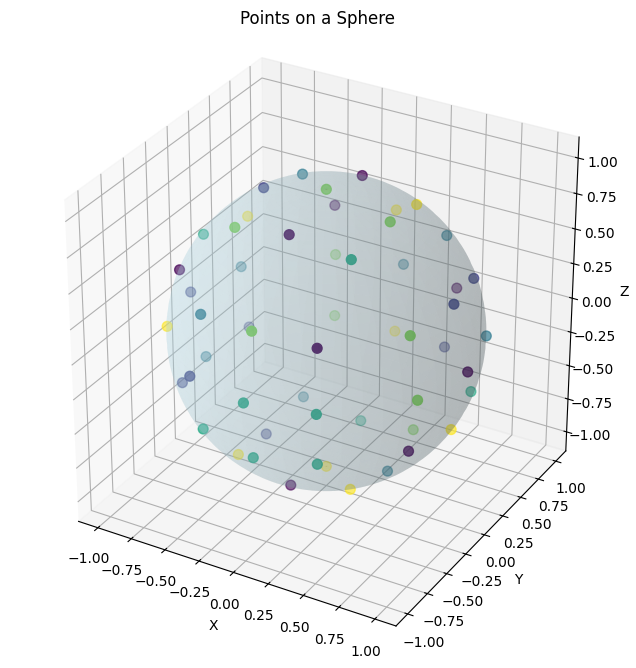

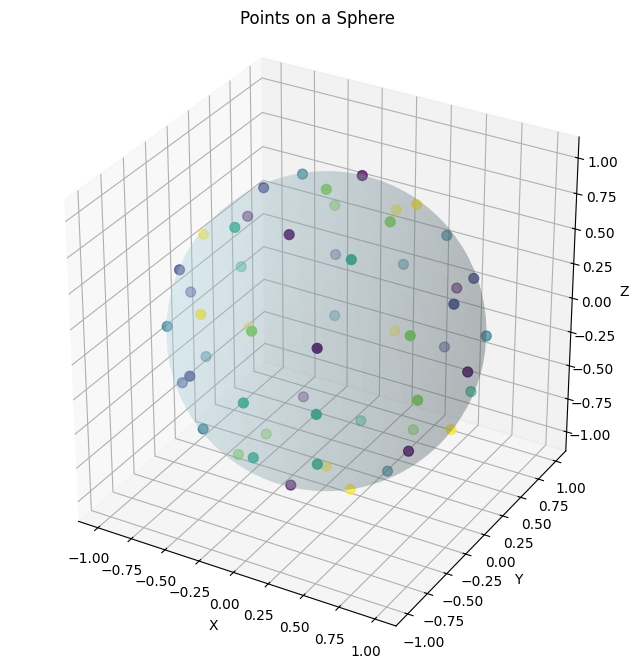

In [4]:
env = RubiksCube()
env.reset()
env.render()
env.move(5)
env.render()


### Test observation

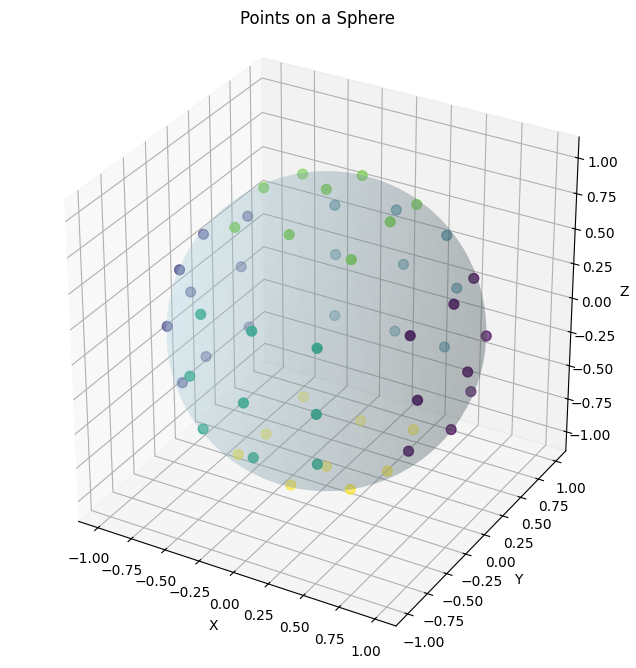

54


[[0, 0, 4],
 [1, 0, 4],
 [2, 0, 4],
 [3, 0, 4],
 [4, 0, 4],
 [5, 0, 4],
 [6, 0, 4],
 [7, 0, 4],
 [8, 0, 4],
 [9, 1, 5],
 [10, 1, 5],
 [11, 1, 5],
 [12, 1, 5],
 [13, 1, 5],
 [14, 1, 5],
 [15, 1, 5],
 [16, 1, 5],
 [17, 1, 5],
 [18, 2, 1],
 [19, 2, 1],
 [20, 2, 1],
 [21, 2, 1],
 [22, 2, 1],
 [23, 2, 1],
 [24, 2, 1],
 [25, 2, 1],
 [26, 2, 1],
 [27, 3, 0],
 [28, 3, 0],
 [29, 3, 0],
 [30, 3, 0],
 [31, 3, 0],
 [32, 3, 0],
 [33, 3, 0],
 [34, 3, 0],
 [35, 3, 0],
 [36, 4, 3],
 [37, 4, 3],
 [38, 4, 3],
 [39, 4, 3],
 [40, 4, 3],
 [41, 4, 3],
 [42, 4, 3],
 [43, 4, 3],
 [44, 4, 3],
 [45, 5, 2],
 [46, 5, 2],
 [47, 5, 2],
 [48, 5, 2],
 [49, 5, 2],
 [50, 5, 2],
 [51, 5, 2],
 [52, 5, 2],
 [53, 5, 2]]

In [15]:
# action_map = {
#             0:['top',1],
#             1:['top',-1],
#             2:['bottom',1],
#             3:['bottom',-1],
#             4:['left',1],
#             5:['left',-1],
#             6:['right',1],
#             7:['right',-1],
#             8:['front',1],
#             9:['front',-1],
#             10:['back',1],
#             11:['back',-1],
        # }
env = RubiksCube()
env.reset(n_scramble=0)

# def sort_by_first_three(arr):
#     arr = np.asarray(arr)
    
#     if arr.ndim != 2 or arr.shape[1] != 4:
#         raise ValueError("arr must have shape (n, 4)")
    
#     idx = np.lexsort((arr[:, 2], arr[:, 1], arr[:, 0]))
#     return arr[idx]
colors_before = np.array([int(p[3]) for p in env.state])
env.move(0)
env.move(0)
env.move(0)
env.move(0)
# env.move(0)
env.render()
colors_after = np.array([int(p[3]) for p in env.state])#accidentally recreated 19 mismatch by not sorting the state when moves were commented out
moved_points = [[i,b,a] for i,(b,a) in enumerate(zip(colors_before,colors_after)) if b != a]
print(len(moved_points))
moved_points
#conclusion: the way im ordering the points in the obs array is inconsistent after moving

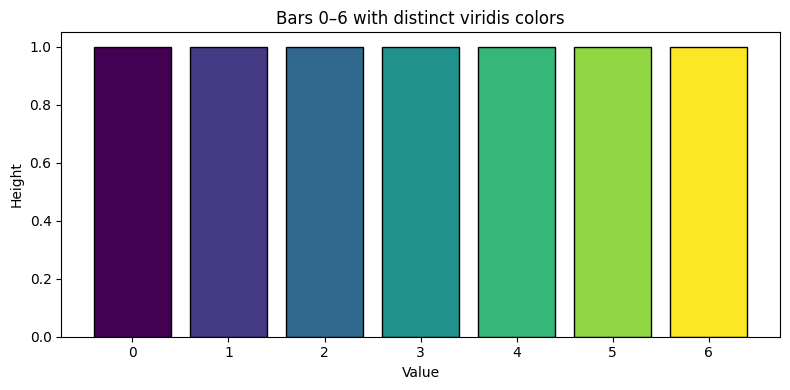

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# x positions 0..6
x = np.arange(0,7)
y = np.ones_like(x)  # all bars same height

# one distinct color per bar from viridis
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, 7))  # 7 colors for 0..6

plt.figure(figsize=(8, 4))
plt.bar(x, y, color=colors, edgecolor='black')
plt.xticks(x, [str(i) for i in x])
plt.xlabel("Value")
plt.ylabel("Height")
plt.title("Bars 0–6 with distinct viridis colors")
plt.tight_layout()
plt.show()

## Model

### Define Model

In [7]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GAMMA = 0.9999
# GAMMA = 1.0
LR = 1e-6
HIDDEN_SIZE = 128*2
HIDDEN_LAYERS = 2
NUM_EPISODES = 10_000
# NUM_EPISODES = 20

class RNNPolicy(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.input_proj = nn.Linear(obs_size, hidden_size,dtype=torch.float32)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True,num_layers=HIDDEN_LAYERS,dropout=0.1)
        self.policy_head = nn.Linear(hidden_size, n_actions)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        inpt = self.input_proj(x)
        x = torch.tanh(inpt)
        x = x.unsqueeze(1)              # [batch, 1, hidden]
        out, h = self.gru(x, h)         # out: [batch, 1, hidden]
        out = out.squeeze(1)            # [batch, hidden]
        logits = self.policy_head(out)
        value = self.value_head(out).squeeze(-1)
        return logits, value, h

    def init_hidden(self, batch_size=1):
        return torch.zeros(self.gru.num_layers, batch_size, HIDDEN_SIZE, device=DEVICE)

class MLPPolicy(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_size, n_actions, dtype=torch.float32)
        self.value_head = nn.Linear(hidden_size, 1, dtype=torch.float32)

    def forward(self, x, h=None):
        x = self.backbone(x)
        logits = self.policy_head(x)
        value = self.value_head(x).squeeze(-1)
        return logits, value, None

    def init_hidden(self, batch_size=1):
        return None

In [8]:
env = RubiksCube()
# env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

# model = RNNPolicy(obs_size, HIDDEN_SIZE, n_actions).to(DEVICE)
model = MLPPolicy(obs_size, HIDDEN_SIZE, n_actions).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

In [9]:
torch.__version__,DEVICE

('2.0.0+cu118', device(type='cuda'))

### Train Model

In [10]:
def run_episode(env, model, episode_number):
    action_hist = np.array([1e-8] * env.action_space.n)
    # obs, info = env.reset(n_scramble = episode_number//100 if episode_number < 500 else 30) #for the first 500, only make 1,2,3,4, or 5 moves from the solved state. 
    #                                                                                         #Then, sufficiently randomize the cube (which apparently is about 30)  
    # obs, info = env.reset(n_scramble = episode_number % 30) #for the first 500, only make 1,2,3,4, or 5 moves from the solved state. 
    obs, info = env.reset(n_scramble = 1) 
    # obs, info = env.reset()
    h = model.init_hidden(batch_size=1) #init hidden state

    log_probs = []
    values = []
    rewards = []

    done = False
    total_reward = 0.0
    # alpha=max(2**2,100-episode_number)#start with large alpha to promote exporation, but keep a min alpha to add some randomness
    alpha=0.01
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)  #convert obs to tensor
        
        # Detach hidden so we don't backprop indefinitely through time
        # h = tuple(x.detach() for x in h) if isinstance(h, tuple) else h.detach()
        logits, value, h = model(obs_t, h) # get model prediciton
        pre_mod_argmax = logits.argmax()

        penalty = alpha * (action_hist / (action_hist.max() + 1e-8))  # in [0, alpha]
        penalty = torch.from_numpy(penalty).to(logits.device).type_as(logits)
        logits = logits - penalty

        
        #Get action by sampling probabilities
        probs = torch.softmax(logits, dim=-1) #convert model output to probabilities
        
        dist = Categorical(probs)
        action = dist.sample()

        #advance state
        next_obs, reward, terminated, truncated, info = env.step(action.item()) #get observations and  from env
        done = terminated or truncated

        #record info
        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)
        action_hist[action]+=1

        obs = next_obs
        total_reward += reward 
    return log_probs, values, rewards, total_reward,action_hist

def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R # add discounted future rewards to current reward step
        returns.append(R) # log reward
    returns.reverse()
    returns = torch.tensor(returns, dtype=torch.float32, device=DEVICE) #convert to tensor
    if len(returns) != 1:
        returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8) # normalize
    else:
        returns = returns/(returns+1e-8) #without this, if length is 1, returns is zero 
    return returns
    
def load_or_create_model(model_class, some_path, device="cuda", *model_args, **model_kwargs):
    model = model_class(*model_args, **model_kwargs)
    path = Path(some_path)

    if path.exists():
        state_dict = torch.load(path, map_location=device)
        model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    return model


#### Pretrain on low-scramble cubes

In [11]:
# env.max_steps = 3
num_pretrain_episodes = 12*10_000
save_path = 'models/rubiks_solver_mlp_5-22.pth'
model = load_or_create_model(MLPPolicy,save_path,obs_size=obs_size, hidden_size=HIDDEN_SIZE, n_actions=n_actions)
optimizer = optim.Adam(model.parameters(), lr=LR)
all_episode_losses = []  # length = num_pretrain_episodes

episodes_per_move = num_pretrain_episodes // n_actions
for move in range(n_actions):
    episode_losses = []

    for i in range(episodes_per_move):
        if i % 100 == 0:
            print('episode',move*episodes_per_move + i)
        episode_idx = move * episodes_per_move + i  # global episode index

        env.reset(n_scramble=0)
        env.move(move)

        log_probs, values, rewards, total_reward, action_history = run_episode(
            env, model, episode_number=episode_idx
        )
        returns = compute_returns(rewards, GAMMA)

        log_probs = torch.cat(log_probs)
        values = torch.cat(values)

        advantages = returns - values.detach()
        policy_loss = -(log_probs * advantages).sum()
        value_loss = nn.functional.mse_loss(values, returns)

        loss = policy_loss + 0.5 * value_loss

        # store per‑episode (detach so we keep a float, not a graph)
        all_episode_losses.append(loss.item())
        episode_losses.append(loss)

    # batched update for this move
    optimizer.zero_grad()
    batch_loss = torch.stack(episode_losses).mean()
    batch_loss.backward()
    # nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

torch.save(model.state_dict(), save_path)

plt.figure(figsize=(8, 4))
plt.plot(all_episode_losses, label="Episode loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("Policy+Value Loss per Episode")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

episode 0


KeyboardInterrupt: 

In [ ]:
# total parameters (including non-trainable)
total_params = sum(p.numel() for p in model.parameters())
print("Total params:", total_params)

# only trainable parameters (requires_grad=True)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", trainable_params)

#### Online Training

In [ ]:

# env = gym.make("CartPole-v1")
# env.reset()
env.reset(n_scramble=0)
# env.max_steps = 100

reward_history = []
loss_history = []
action_history_history = []

for episode in range(1, NUM_EPISODES + 1):
    model.train()
    before = []
    for p in model.parameters():
        before.append(p.detach().clone())
    log_probs, values, rewards, total_reward,action_history = run_episode(env, model,episode_number=episode)
    returns = compute_returns(rewards, GAMMA)

    log_probs = torch.cat(log_probs)
    values = torch.cat(values)

    advantages = returns - values.detach()
    policy_loss = -(log_probs * advantages).sum()
    value_loss = nn.functional.mse_loss(values, returns)
    loss = policy_loss + 0.5 * value_loss
    loss_history.append(loss)
    
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    for name, p in model.named_parameters():
        if p.requires_grad and not torch.isfinite(p).all():
            print("Non-finite param after step:", name)
            print("param min/max:", p.min().item(), p.max().item())
            break
    reward_history.append(total_reward)
    action_history_history.append(action_history)
    if episode % 10 == 0:
        avg_reward = np.mean(reward_history[-10:])
        print(f"Episode {episode:4d} | avg reward {avg_reward:7.2f}")

    if episode % 1000 == 0:
        plt.subplot(1,2,1)
        plt.title('Loss per Episode')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.plot([hist.cpu().detach().numpy() for hist in loss_history])
        
        plt.subplot(1,2,2)
        plt.title('Action Frequency')
        plt.ylabel('count')
        plt.xlabel('action')
        plt.bar(np.arange(len(action_history_history[0])),sum(np.array(action_history_history)))
        
        
        plt.show()
        torch.save(model.state_dict(), save_path)

    
    after = []
    for p in model.parameters():
        after.append(p.detach().clone())
    
    # check if anything changed
    none_changed = not(any((b != a).any().item() for b, a in zip(before, after)))
    if none_changed:
        print("Weights identical after training :(")


In [ ]:
torch.save(model.state_dict(), save_path)

env.close()


### Plot Session Info

In [ ]:
plt.subplot(1,2,1)
plt.title('Loss per Episode')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.plot([hist.cpu().detach().numpy() for hist in loss_history])

plt.subplot(1,2,2)
plt.title('Action Frequency')
plt.ylabel('count')
plt.xlabel('action')
plt.bar(np.arange(len(action_history_history[0])),sum(np.array(action_history_history)))


plt.show()

In [ ]:
#5/18 wilo:
    #it looks like its training, but learning rate still possibly too high
        #that actually may not be the case. Classically, loss bouncing like this means LR too high but thats assuming a batch of any sort.
        #we have a batch size of 1. Which, i might need to change. Even a batch size of 10 would be more helpful
        #because of the batch size, i should focus on the trend of the loss rather than the line itself 
#5/19:
    #earlier we saw the loss drop drastically after about 500 episodes. I thought this was from the model learning, its much more likely that the problem
    #became much easier. The problem went from "sometimes its non-zero" to "its always zero"
    #similarly with the alpha exploration

    #im going to move the action history into the episode def so that it resets each time. 
#5/20:
    #changed reward to reward for each face completed as well as being solved.
    #still having the problem of one action favored
#5/21:
    #heavy bias towards one action, but still seeing completions 
    #after printing returns, i see its working properly EXCEPT the model has zero reward after completion

    #It looks like the model gets to about 3k episodes and then the loss flattens.
#5/22:
    #just tested cartpole again, it starts performing better within 250 episodes. Its definitely not my training script, its my environment
    #what im unsure of, is if its because my env is very difficult, or if its bc theres something wrong. Like the order of the points or something

In [ ]:
sum(np.array(action_history_history))


In [ ]:
sum(np.array(action_history_history))